In [1]:
import os
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Questions to answer:\
1.1 - How does layerwise rep dim change when whole model is pruned? \
1.2 - How does layerwise rep dim change when only that layer is pruned? \
1.3 - Is layerwise rep dim change predictive of model performance changes? \


### Helper Functions

In [2]:
def read_results(prune_method='random', metric="eff_dim", prune_all=True, model_name='vgg'):
    assert prune_method in ['random', 'amp', 'svd']
    assert metric in ['eff_dim', 'pca_dim', 'val_acc']
    assert model_name in ['vgg']

    results_file = f'./results/{model_name}_{metric}_{prune_method}_{"all" if prune_all else "layerwise"}.csv'

    df = pd.read_csv(results_file)


    # if there is a layer_name == Input, drop it and store the layer names in a list
    if 'layer_name' in df.columns:
        df = df[df['layer_name'] != 'Input']

    
    if metric == 'eff_dim' or metric == 'pca_dim': # return np array of [n_layers x n_sparsity_levels]
        res = df.iloc[:, 1:].to_numpy()
    
    elif metric == 'val_acc' and prune_all: # return np array of [n_sparsity_levels,2] 2 for top1 and top5
        res = df.to_numpy().T.astype(float)
    
    elif metric == 'val_acc' and not prune_all: # return np array of [n_layers, n_sparsity_levels, 2] 2 for top1 and top5
        res = df.iloc[:, 1:].to_numpy()
        res = np.array([[ast.literal_eval(x) for x in row] for row in res]).astype(float) # convert string representation of list to list of floats
    
    
    return res

def get_layer_names(prune_method='random', metric="eff_dim", prune_all=True, model_name='vgg'):
    assert prune_method in ['random', 'amp', 'svd']
    assert metric in ['eff_dim', 'pca_dim', 'val_acc']
    assert model_name in ['vgg']

    results_file = f'./results/{model_name}_{metric}_{prune_method}_{"all" if prune_all else "layerwise"}.csv'

    df = pd.read_csv(results_file)

    if 'layer_name' in df.columns:
        layer_names = df['layer_name'].to_list()
        layer_names = [name for name in layer_names if name != 'Input']
        return layer_names
    else:
        return None
    
def get_sparsity_levels(prune_method='random', metric="eff_dim", prune_all=True, model_name='vgg'):
    assert prune_method in ['random', 'amp', 'svd']
    assert metric in ['eff_dim', 'pca_dim', 'val_acc']
    assert model_name in ['vgg']

    results_file = f'./results/{model_name}_{metric}_{prune_method}_{"all" if prune_all else "layerwise"}.csv'

    df = pd.read_csv(results_file)

    sparsity_levels = df.columns[1:].to_list() # first column is layer name
    sparsity_levels = [float(s.split('sparsity_')[1]) for s in sparsity_levels]
    return sparsity_levels


In [5]:
layer_names = get_layer_names(prune_method='random', metric='eff_dim', prune_all=False)
sparsity_levels = get_sparsity_levels(prune_method='random', metric='eff_dim', prune_all=False)

print(layer_names)
print(sparsity_levels)

['Conv1', 'Conv2', 'Conv3', 'Conv4', 'Conv5', 'Conv6', 'Conv7', 'Conv8', 'Conv9', 'Conv10', 'Conv11', 'Conv12', 'Conv13', 'Linear1', 'Linear2']
[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


### Q1.  How does effective dimensionality change when whole model is pruned?

In [10]:
eff_dims_random_all = read_results(prune_method='random', metric='eff_dim', prune_all=True) #[n_layers x n_sparsity_levels]
eff_dims_amp_all = read_results(prune_method='amp', metric='eff_dim', prune_all=True)
eff_dims_svd_all = read_results(prune_method='svd', metric='eff_dim', prune_all=True)



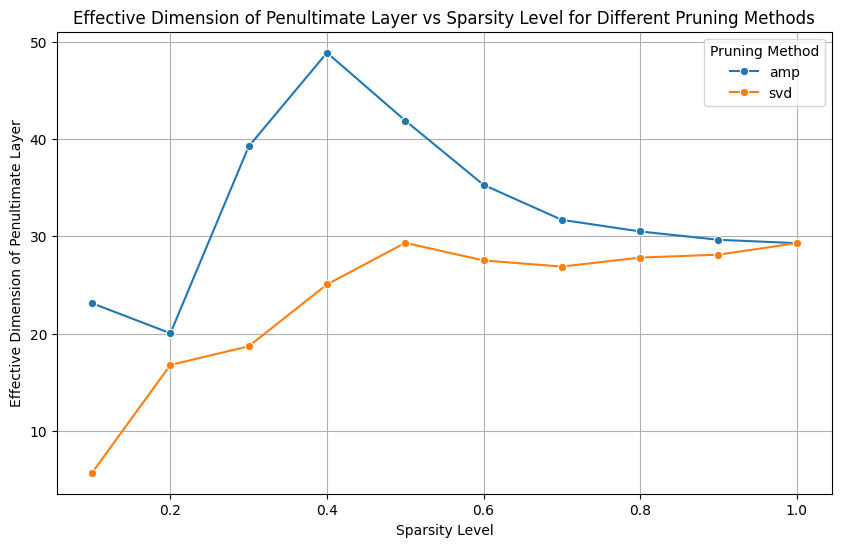

In [6]:
# plot just penultimate layer reps for all 3 methods

# concatenate the results for the penultimate layer across all 3 methods into a df
plot1_df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'penultimate_eff_dim', 'method'])
plot1_df['sparsity_level'] = sparsity_levels*3
plot1_df['penultimate_eff_dim'] = np.concatenate([eff_dims_random_all[-1, :], eff_dims_amp_all[-1, :], eff_dims_svd_all[-1, :]])
plot1_df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  

# remove all random method rows
plot1_df = plot1_df[plot1_df['method'] != 'random']

plt.figure(figsize=(10, 6))
sns.lineplot(data=plot1_df, x='sparsity_level', y='penultimate_eff_dim', hue='method', marker='o')
plt.title('Effective Dimension of Penultimate Layer vs Sparsity Level for Different Pruning Methods')
plt.xlabel('Sparsity Level')
plt.ylabel('Effective Dimension of Penultimate Layer')
plt.legend(title='Pruning Method')
plt.grid()

In [ ]:
##

### Q2. How does layerwise rep dim change when only that layer is pruned?

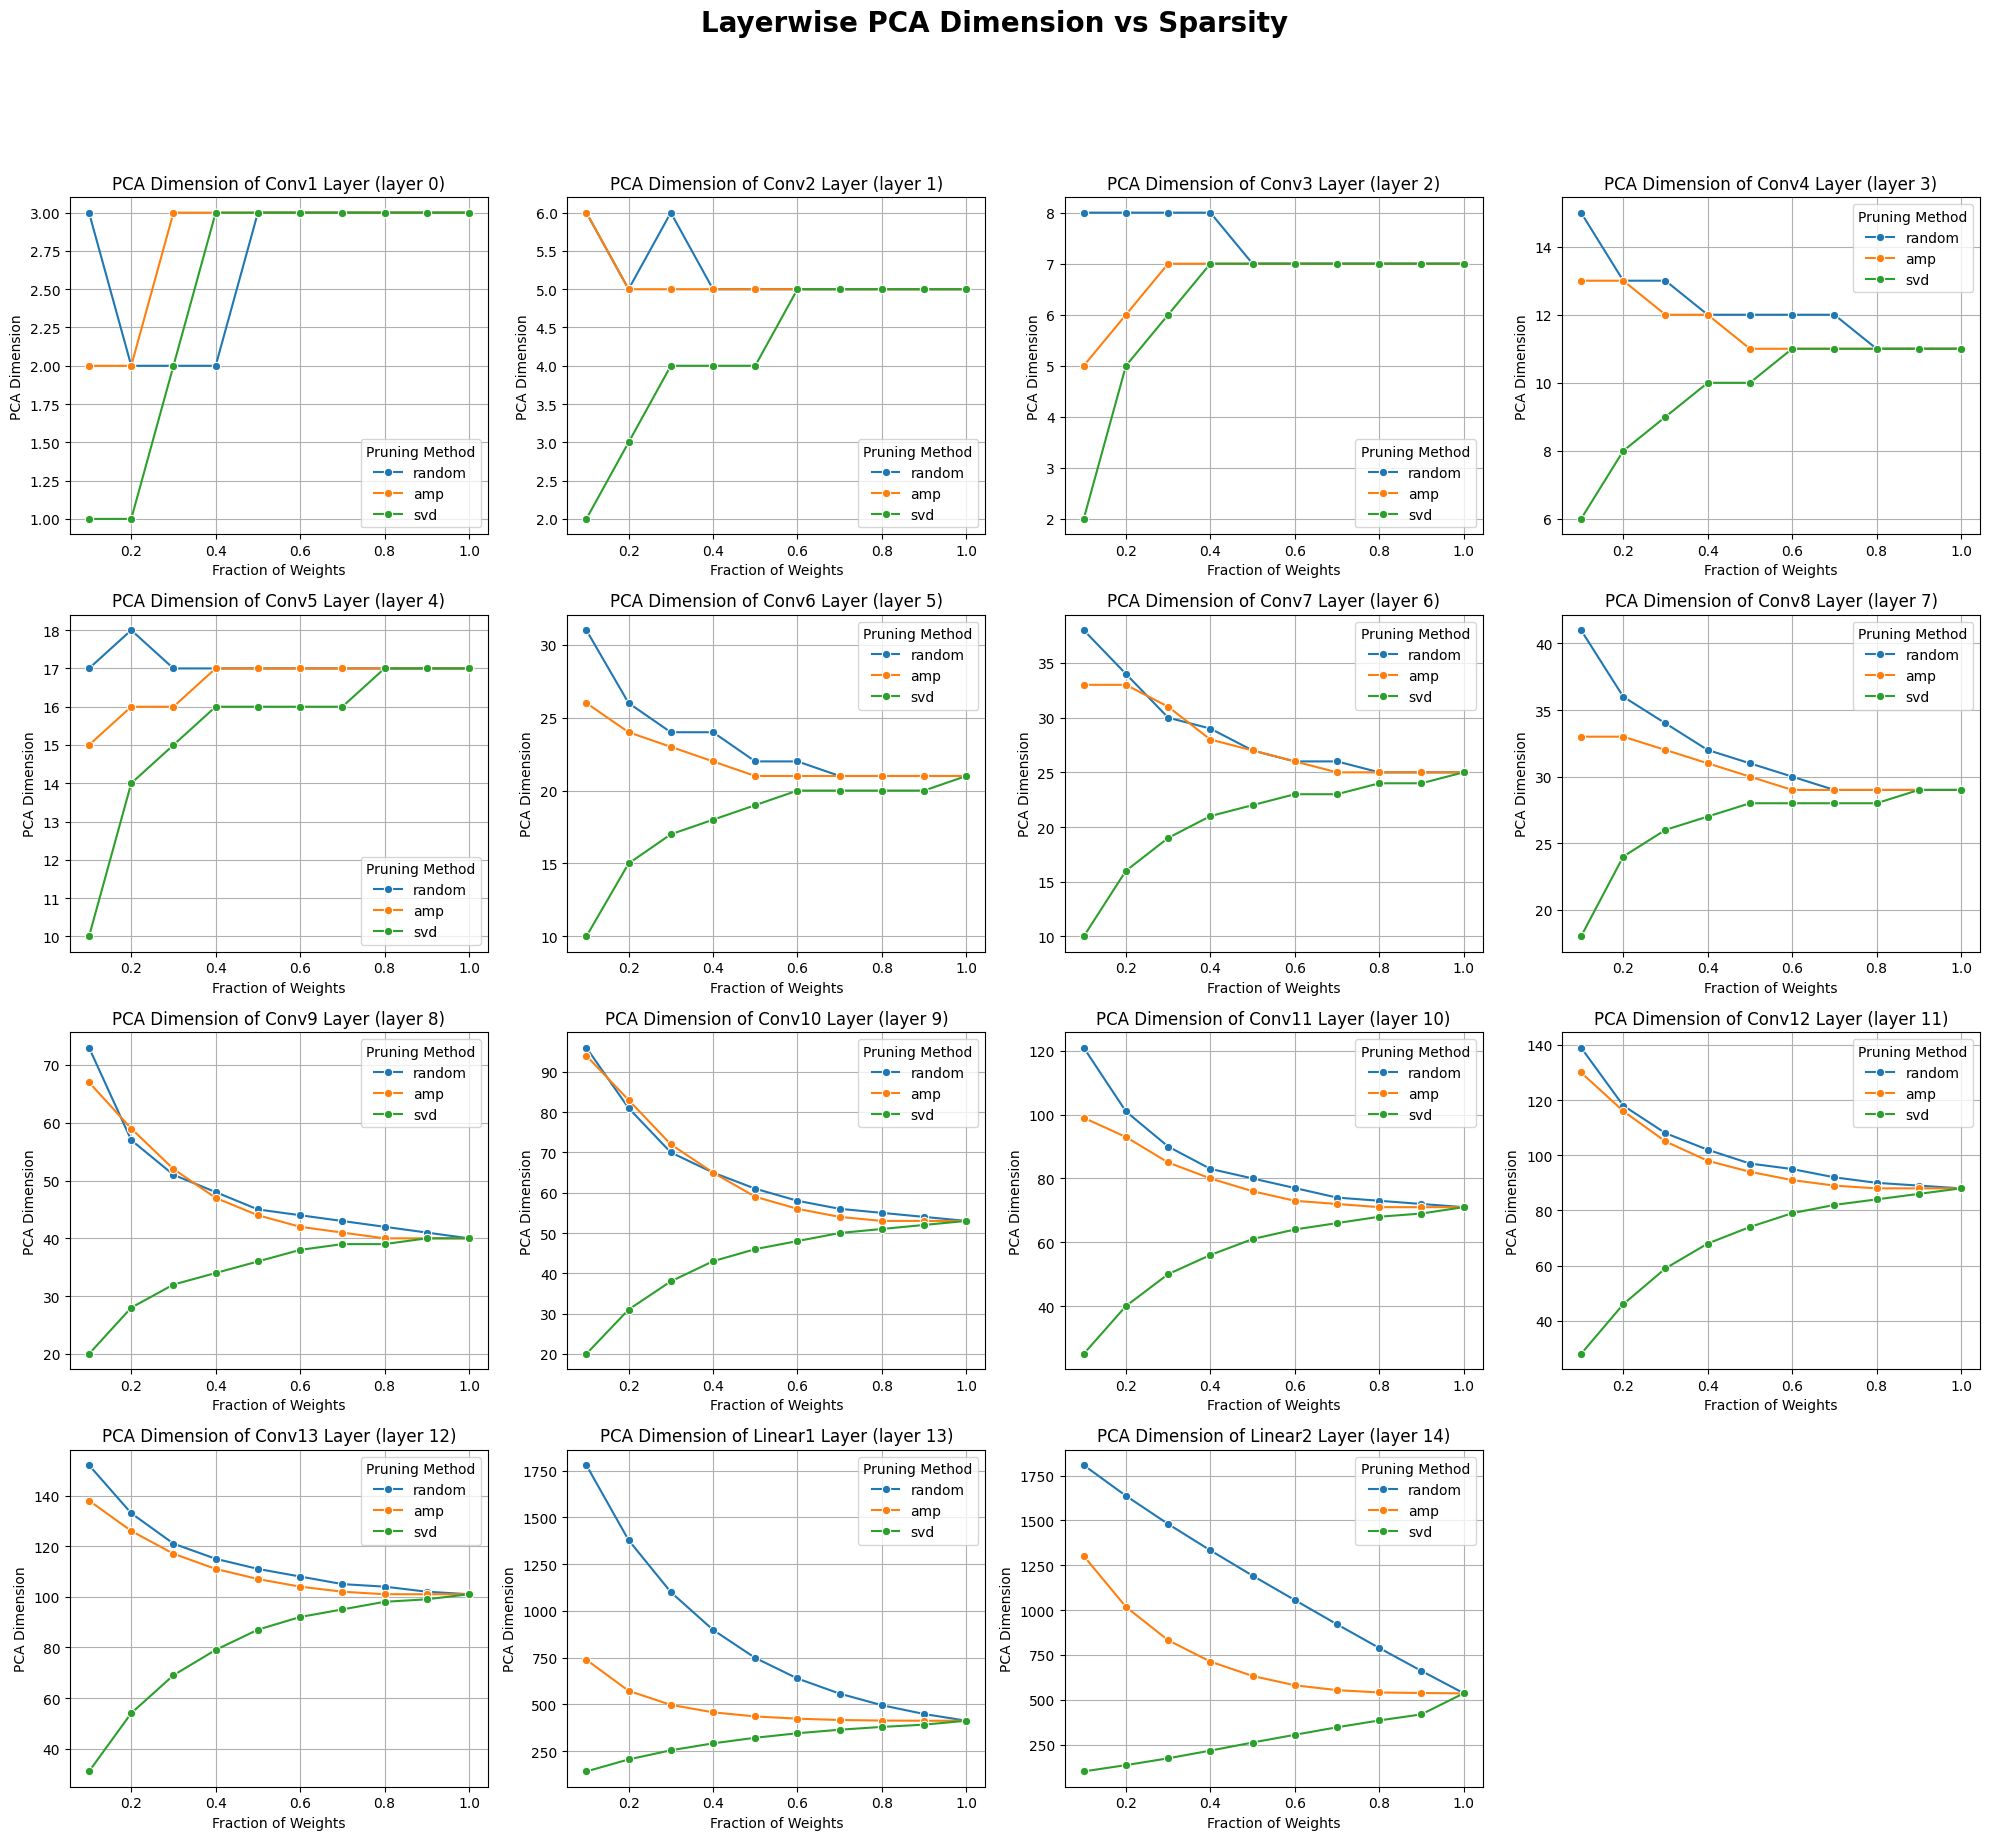

In [ ]:
# subplots for each layer showing how the pca dim changes with sparsity level for each method (all 3 methods)
pca_dims_random_layerwise = read_results(prune_method='random', metric='pca_dim', prune_all=False) #[n_layers x n_sparsity_levels]
pca_dims_amp_layerwise = read_results(prune_method='amp', metric='pca_dim', prune_all=False)
pca_dims_svd_layerwise = read_results(prune_method='svd', metric='pca_dim', prune_all=False)

layer_names = get_layer_names(prune_method='random', metric='pca_dim', prune_all=False)
sparsity_levels = get_sparsity_levels(prune_method='random', metric='pca_dim', prune_all=False)

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 18))

for i, ax in enumerate(axs.flatten()):
    if i < len(layer_names):
        layer_name = layer_names[i]
        df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'pca_dim', 'method'])
        df['sparsity_level'] = sparsity_levels*3
        df['pca_dim'] = np.concatenate([pca_dims_random_layerwise[i, :], pca_dims_amp_layerwise[i, :], pca_dims_svd_layerwise[i, :]])
        df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  
        sns.lineplot(data=df, x='sparsity_level', y='pca_dim', hue='method', marker='o', ax=ax)
        ax.set_title(f'PCA Dimension of {layer_name} Layer (layer {i})')
        ax.set_xlabel('Fraction of Weights')
        ax.set_ylabel('PCA Dimension')
        ax.legend(title='Pruning Method')
        ax.grid()
    else:
        ax.axis('off')

fig.suptitle("Layerwise PCA Dimension vs Sparsity", fontsize=20, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

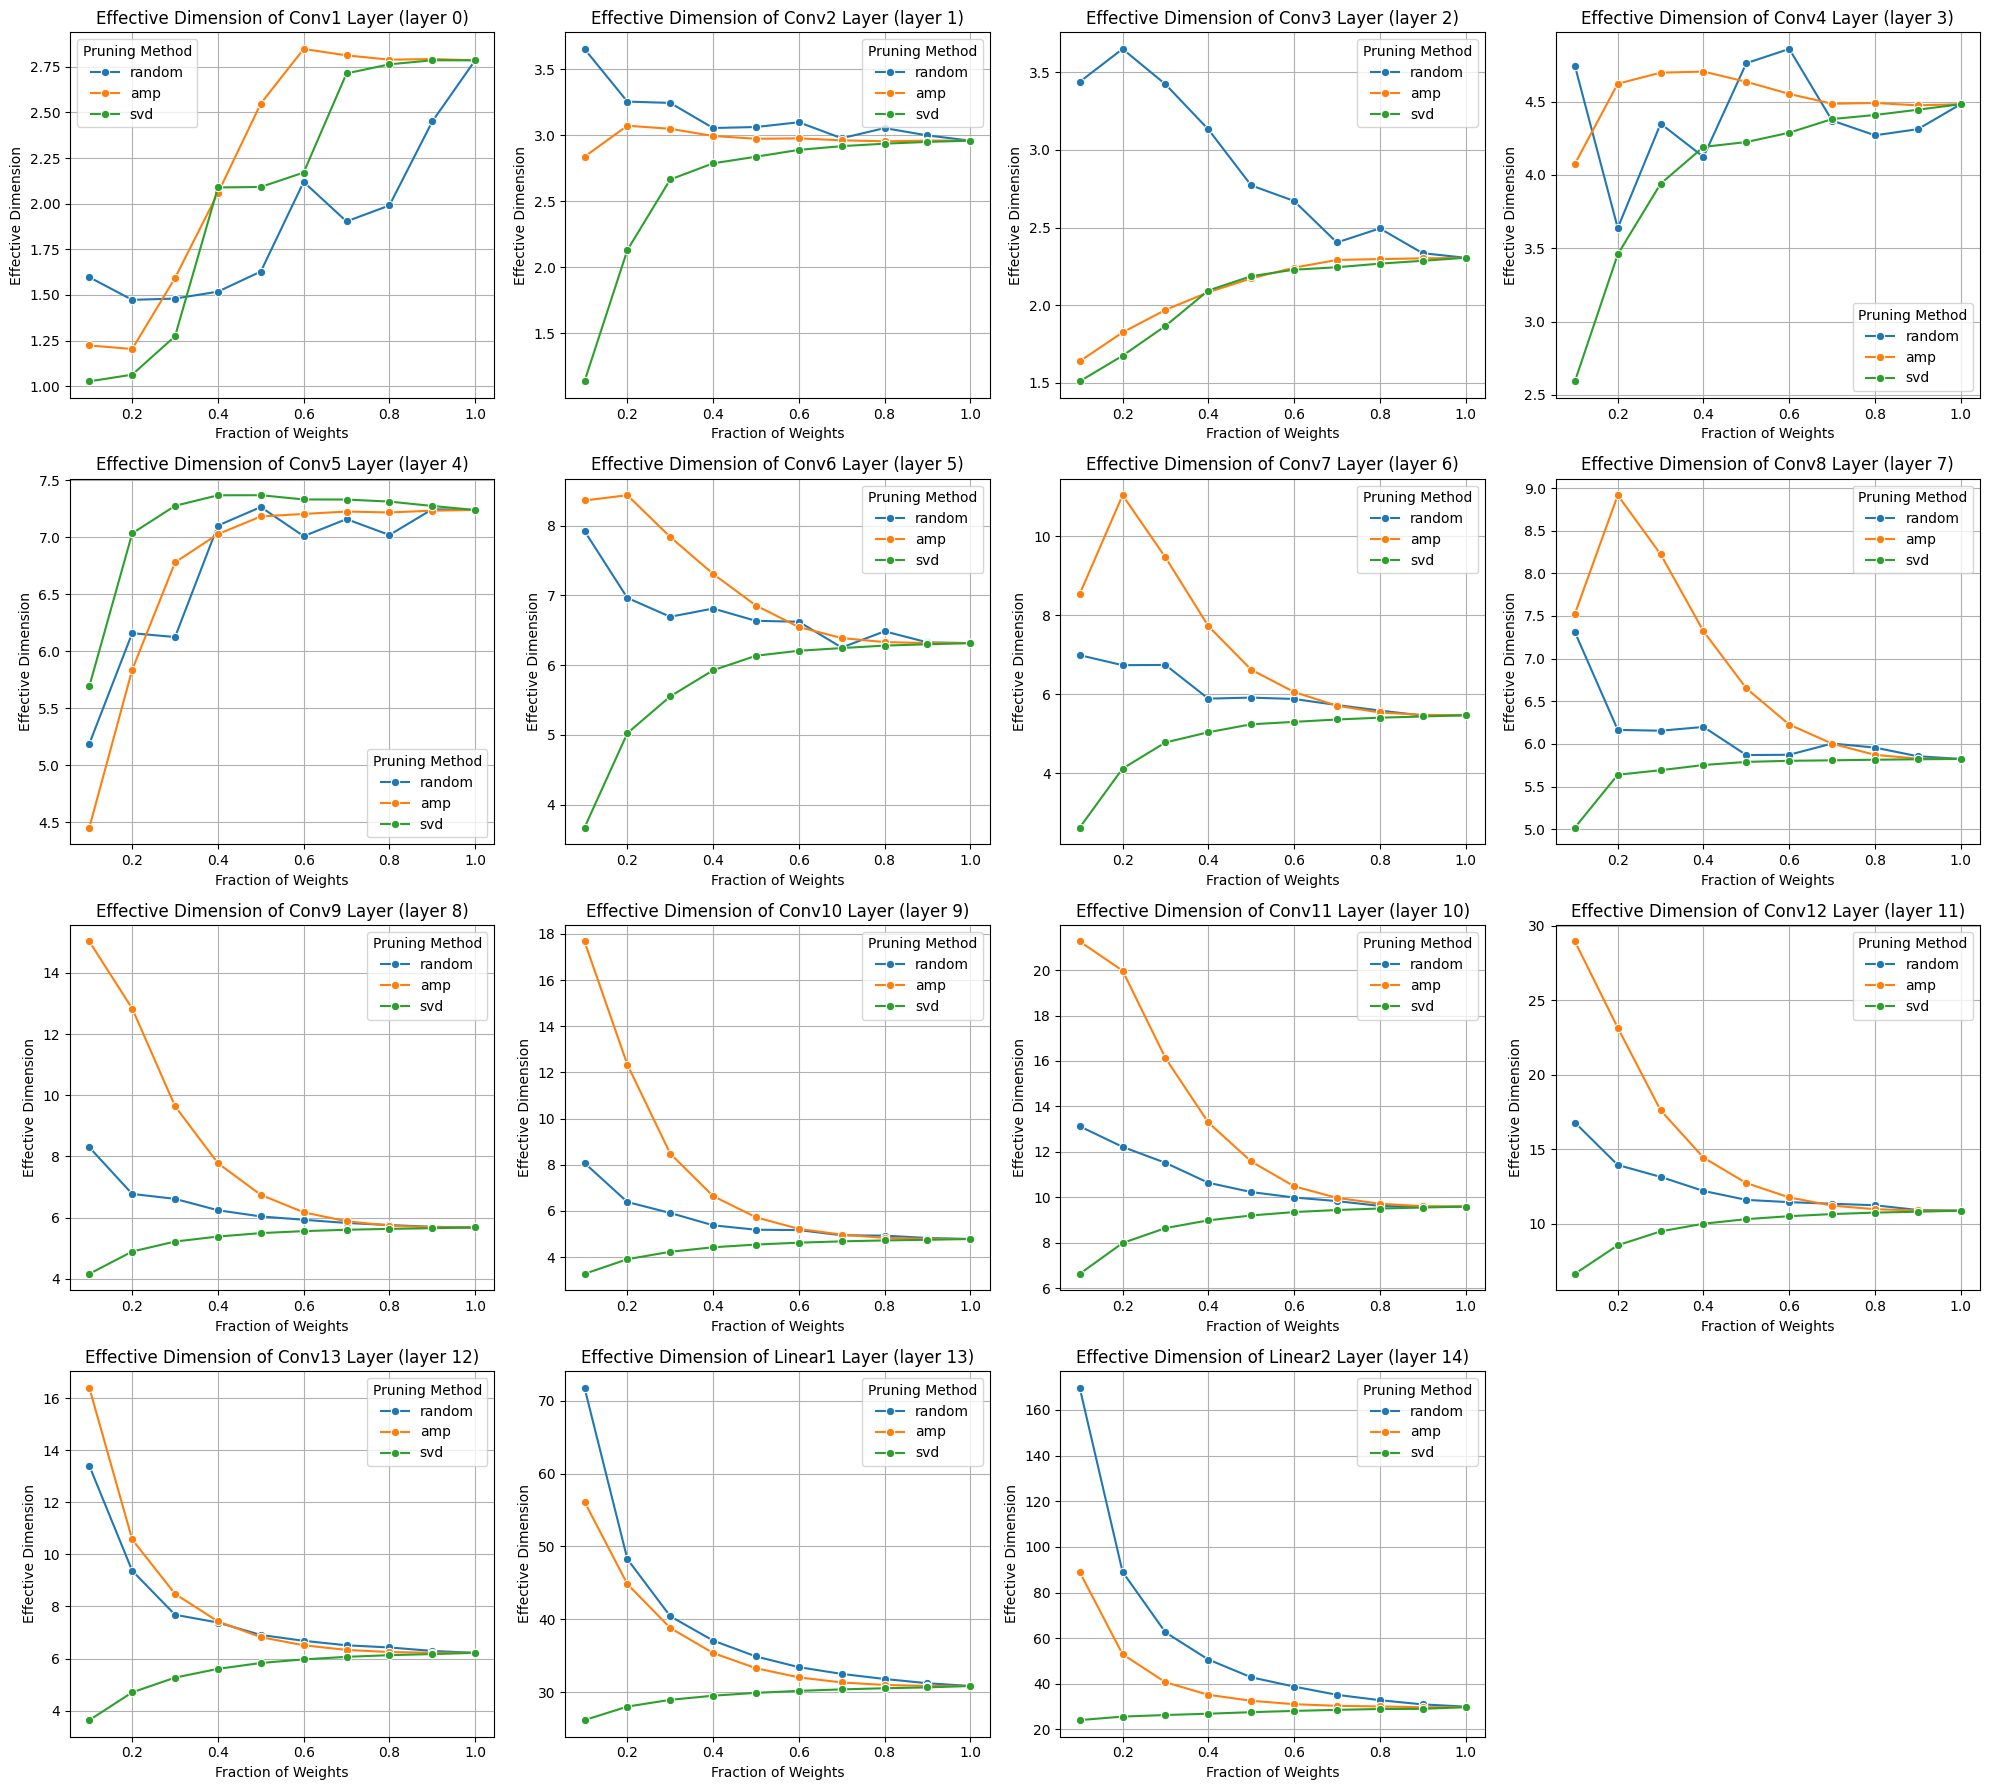

In [4]:
eff_dims_random_layerwise = read_results(prune_method='random', metric='eff_dim', prune_all=False) #[n_layers x n_sparsity_levels]
eff_dims_amp_layerwise = read_results(prune_method='amp', metric='eff_dim', prune_all=False)
eff_dims_svd_layerwise = read_results(prune_method='svd', metric='eff_dim', prune_all=False)


fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 18))

for i, ax in enumerate(axs.flatten()):
    if i < len(layer_names):
        layer_name = layer_names[i]
        df = pd.DataFrame(index=np.arange(len(sparsity_levels)*3), columns=['sparsity_level', 'eff_dim', 'method'])
        df['sparsity_level'] = sparsity_levels*3
        df['eff_dim'] = np.concatenate([eff_dims_random_layerwise[i, :], eff_dims_amp_layerwise[i, :], eff_dims_svd_layerwise[i, :]])
        df['method'] = ['random']*len(sparsity_levels) + ['amp']*len(sparsity_levels) + ['svd']*len(sparsity_levels)  
        sns.lineplot(data=df, x='sparsity_level', y='eff_dim', hue='method', marker='o', ax=ax)
        ax.set_title(f'Effective Dimension of {layer_name} Layer (layer {i})')
        ax.set_xlabel('Fraction of Weights')
        ax.set_ylabel('Effective Dimension')
        ax.legend(title='Pruning Method')
        ax.grid()
    else:
        ax.axis('off')

# plt.suptitle('Effective Dimension of Each Layer after Pruning', fontsize=16)
plt.tight_layout()

### Q3. Is layerwise rep dim change predictive of model performance changes? 

In [ ]:
# plot accuracies across all sparsity levels for all 3 methods (all and layerwise)

In [ ]:
from my_utils.model_helpers import set_seed, init_model, get_layer_names, get_nice_layer_names, get_layer_activations
from my_utils.imagenet import get_imagenet_dataloader, eval_model_val

data_dir = '/mnt/cogsci/KhoslaLab/ILSVRC2012/valid'
dataset_size = 10000
model = init_model('vgg16', trained=True)
data_loader = get_imagenet_dataloader(data_dir, val=True, batch_size=128, num_workers=4, subset_num=dataset_size, shuffle=True)

layer_names = get_layer_names(model)[1:] 
for li, ln in enumerate(layer_names):
    acts = get_layer_activations(model, ln, data_loader, pool_method='global', device_id=2)

['Input', 'Conv1', 'Conv2', 'Conv3', 'Conv4', 'Conv5', 'Conv6', 'Conv7', 'Conv8', 'Conv9', 'Conv10', 'Conv11', 'Conv12', 'Conv13', 'Linear1', 'Linear2']
